In [2]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


# =========================================================
# LOAD PVK SHEET
# =========================================================

file_path = "Data_file.xlsx"
sheet_name = "PVK"

# Load dataset
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Display basic info
print("PVK Sheet Loaded Successfully!")
print("Shape of Dataset:", df.shape)

# Show column names
print("\nColumns in PVK Sheet:")
print(df.columns.tolist())

# Preview first rows
df.head()

PVK Sheet Loaded Successfully!
Shape of Dataset: (61, 42)

Columns in PVK Sheet:
['Jsc', 'v(V)', 't=100[nm]', 't=200[nm]', 't=300[nm]', 't=400[nm]', 't=500[nm]', 't=600[nm]', 't=700[nm]', 't=800[nm]', 't=900[nm]', 't=1000[nm]', 'Unnamed: 12', 'thickness(nm)', 'Jsc(mA/cm^2)', 'Unnamed: 15', 'Unnamed: 16', 'Q.E.(%)', 'lambda(nm)', 't=100[nm].1', 't=200[nm].1', 't=300[nm].1', 't=400[nm].1', 't=500[nm].1', 't=600[nm].1', 't=700[nm].1', 't=800[nm].1', 't=900[nm].1', 't=1000[nm].1', 'Unnamed: 29', 'R(A/W)', 'lambda(nm).1', 't=100[nm].2', 't=200[nm].2', 't=300[nm].2', 't=400[nm].2', 't=500[nm].2', 't=600[nm].2', 't=700[nm].2', 't=800[nm].2', 't=900[nm].2', 't=1000[nm].2']


,Jsc,v(V),t=100[nm],t=200[nm],t=300[nm],t=400[nm],t=500[nm],t=600[nm],t=700[nm],t=800[nm],...,t=100[nm].2,t=200[nm].2,t=300[nm].2,t=400[nm].2,t=500[nm].2,t=600[nm].2,t=700[nm].2,t=800[nm].2,t=900[nm].2,t=1000[nm].2
0,NaN,0.00,15.656240,18.372112,20.060791,21.146976,21.870996,22.369520,22.722777,22.979425,...,0.194423,0.202371,0.204799,0.205526,0.205744,0.205811,0.205837,0.205848,0.205856,0.205863
1,-1.0,0.05,15.652868,18.371067,20.060271,21.146661,21.870780,22.369357,22.722645,22.979312,...,0.202299,0.211150,0.213947,0.214813,0.215080,0.215166,0.215197,0.215211,0.215220,0.215227
2,NaN,0.10,15.649539,18.370021,20.059748,21.146342,21.870560,22.369191,22.722510,22.979194,...,0.210272,0.220096,0.223304,0.224329,0.224656,0.224763,0.224802,0.224818,0.224828,0.224837
3,NaN,0.15,15.646249,18.368974,20.059220,21.146019,21.870336,22.369021,22.722371,22.979073,...,0.218369,0.229242,0.232907,0.234115,0.234512,0.234645,0.234694,0.234714,0.234726,0.234735
4,NaN,0.20,15.642996,18.367923,20.058686,21.145690,21.870108,22.368846,22.722226,22.978946,...,0.226631,0.238641,0.242814,0.244232,0.244712,0.244877,0.244938,0.244962,0.244976,0.244986


In [3]:
# =========================================================
# EXTRACT J-V DATA
# =========================================================

# Select voltage + J-V columns only
jv_cols = ['v(V)'] + [
    col for col in df.columns
    if str(col).startswith('t=') and '.1' not in str(col) and '.2' not in str(col)
]

jv_df = df[jv_cols]

# Convert wide to long format
jv_long = jv_df.melt(
    id_vars='v(V)',
    var_name='Thickness',
    value_name='Current'
)

# Extract thickness value
jv_long['Thickness'] = jv_long['Thickness'].str.extract(r't=(\d+)').astype(float)

# Remove NaN values
jv_long.dropna(inplace=True)

# Rename voltage column
jv_long.rename(columns={'v(V)': 'Voltage'}, inplace=True)

print("J-V Data Ready!")
jv_long.head()

J-V Data Ready!


,Voltage,Thickness,Current
0,0.00,100.0,15.656240
1,0.05,100.0,15.652868
2,0.10,100.0,15.649539
3,0.15,100.0,15.646249
4,0.20,100.0,15.642996


In [4]:
# =========================================================
# EXTRACT QE DATA
# =========================================================

# Select wavelength + QE columns only
qe_cols = ['lambda(nm)'] + [
    col for col in df.columns
    if str(col).startswith('t=') and '.1' in str(col)
]

qe_df = df[qe_cols]

# Convert wide to long format
qe_long = qe_df.melt(
    id_vars='lambda(nm)',
    var_name='Thickness',
    value_name='QE'
)

# Extract thickness value
qe_long['Thickness'] = qe_long['Thickness'].str.extract(r't=(\d+)').astype(float)

# Remove NaN values
qe_long.dropna(inplace=True)

# Rename wavelength column
qe_long.rename(columns={'lambda(nm)': 'Wavelength'}, inplace=True)

print("QE Data Ready!")
qe_long.head()

QE Data Ready!


,Wavelength,Thickness,QE
0,300,100.0,80.36131
1,310,100.0,80.91970
2,320,100.0,81.48047
3,330,100.0,82.05365
4,340,100.0,82.65374


In [5]:
# =========================================================
# EXTRACT RESPONSIVITY DATA
# =========================================================

# Select wavelength + Responsivity columns only
r_cols = ['lambda(nm).1'] + [
    col for col in df.columns
    if str(col).startswith('t=') and '.2' in str(col)
]

r_df = df[r_cols]

# Convert wide to long format
r_long = r_df.melt(
    id_vars='lambda(nm).1',
    var_name='Thickness',
    value_name='Responsivity'
)

# Extract thickness value
r_long['Thickness'] = r_long['Thickness'].str.extract(r't=(\d+)').astype(float)

# Remove NaN values
r_long.dropna(inplace=True)

# Rename wavelength column
r_long.rename(columns={'lambda(nm).1': 'Wavelength'}, inplace=True)

print("Responsivity Data Ready!")
r_long.head()

Responsivity Data Ready!


,Wavelength,Thickness,Responsivity
0,300,100.0,0.194423
1,310,100.0,0.202299
2,320,100.0,0.210272
3,330,100.0,0.218369
4,340,100.0,0.226631


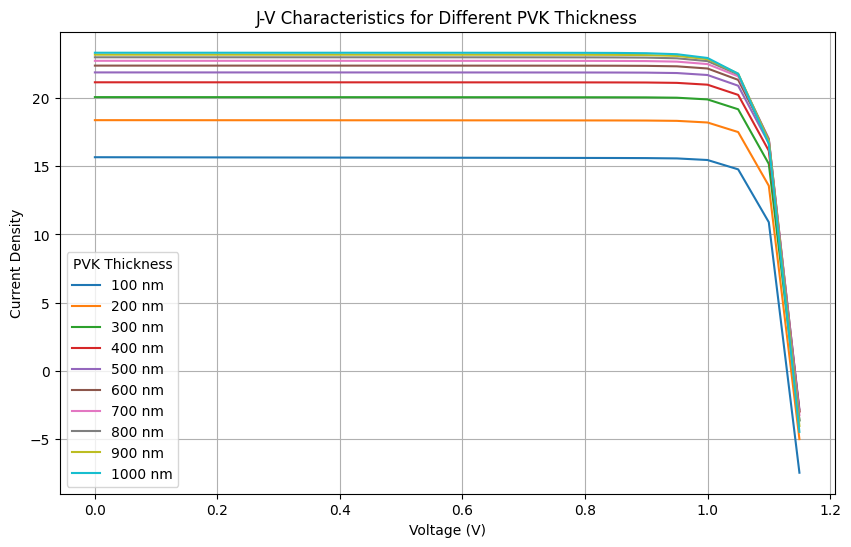

In [6]:
# =========================================================
# PLOT J-V CURVES
# =========================================================

plt.figure(figsize=(10,6))

for thickness in sorted(jv_long['Thickness'].unique()):
    subset = jv_long[jv_long['Thickness'] == thickness]

    plt.plot(
        subset['Voltage'],
        subset['Current'],
        label=f'{int(thickness)} nm'
    )

plt.title("J-V Characteristics for Different PVK Thickness")
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density")
plt.legend(title="PVK Thickness")
plt.grid(True)
plt.show()

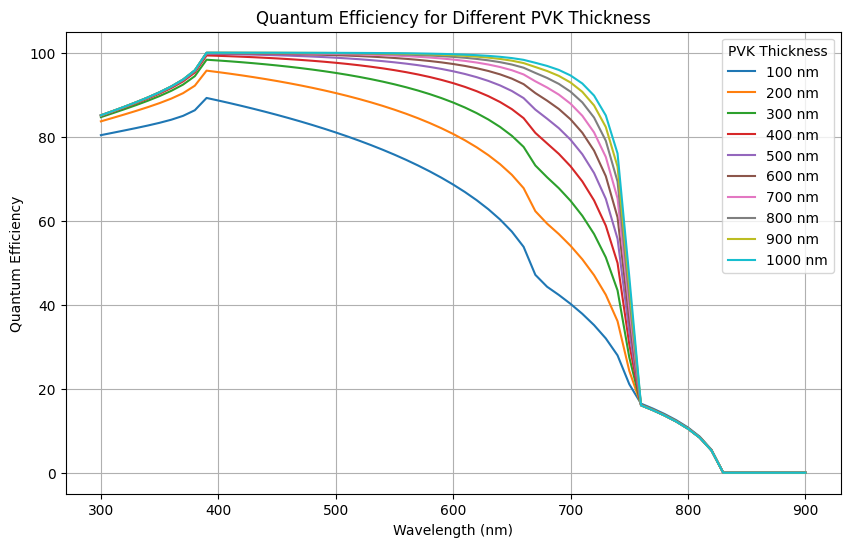

In [7]:
# =========================================================
# PLOT QE CURVES
# =========================================================

plt.figure(figsize=(10,6))

for thickness in sorted(qe_long['Thickness'].unique()):
    subset = qe_long[qe_long['Thickness'] == thickness]

    plt.plot(
        subset['Wavelength'],
        subset['QE'],
        label=f'{int(thickness)} nm'
    )

plt.title("Quantum Efficiency for Different PVK Thickness")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Quantum Efficiency")
plt.legend(title="PVK Thickness")
plt.grid(True)
plt.show()

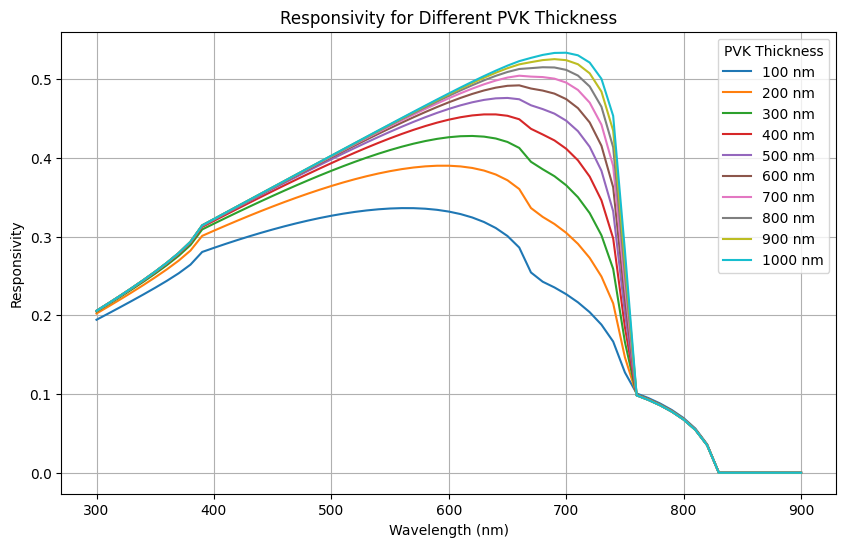

In [8]:
# =========================================================
# PLOT RESPONSIVITY CURVES
# =========================================================

plt.figure(figsize=(10,6))

for thickness in sorted(r_long['Thickness'].unique()):
    subset = r_long[r_long['Thickness'] == thickness]

    plt.plot(
        subset['Wavelength'],
        subset['Responsivity'],
        label=f'{int(thickness)} nm'
    )

plt.title("Responsivity for Different PVK Thickness")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Responsivity")
plt.legend(title="PVK Thickness")
plt.grid(True)
plt.show()

J-V Model Performance
R² Score: 0.9986561994388936
MAE: 0.056655068318745914


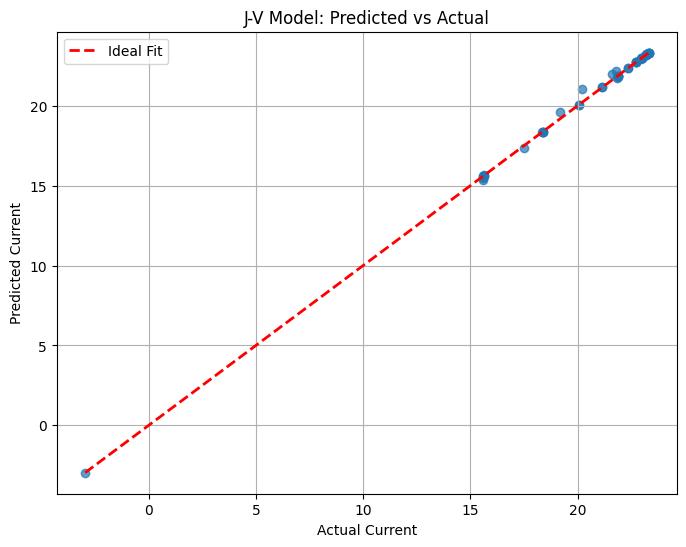

In [10]:
# =========================================================
# J-V MACHINE LEARNING MODEL
# =========================================================

# Features and target
X_jv = jv_long[['Voltage', 'Thickness']]
y_jv = jv_long['Current']

# Train-test split
X_train_jv, X_test_jv, y_train_jv, y_test_jv = train_test_split(
    X_jv, y_jv,
    test_size=0.2,
    random_state=42
)

# Model
jv_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
jv_model.fit(X_train_jv, y_train_jv)

# Predict
y_pred_jv = jv_model.predict(X_test_jv)

# Metrics
print("J-V Model Performance")
print("R² Score:", r2_score(y_test_jv, y_pred_jv))
print("MAE:", mean_absolute_error(y_test_jv, y_pred_jv))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_jv, y_pred_jv, alpha=0.7)

# Ideal reference line
min_val = min(y_test_jv.min(), y_pred_jv.min())
max_val = max(y_test_jv.max(), y_pred_jv.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Current")
plt.ylabel("Predicted Current")
plt.title("J-V Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

QE Model Performance
R² Score: 0.999436783289397
MAE: 0.42290661510187716


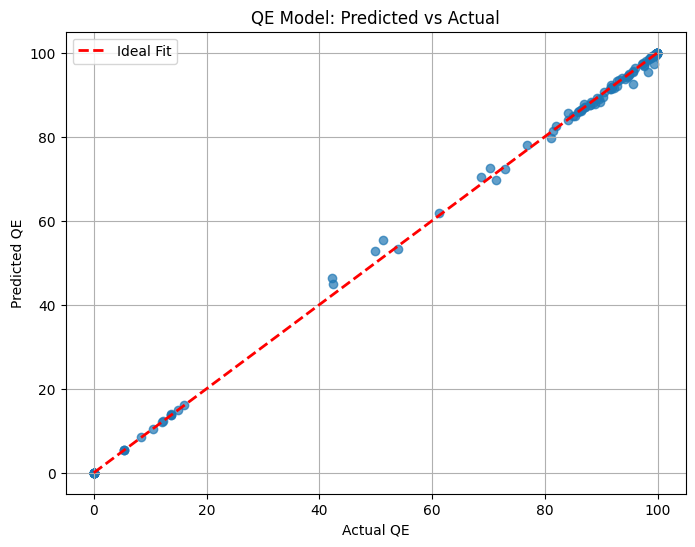

In [12]:
# =========================================================
# QE MACHINE LEARNING MODEL
# =========================================================

# Features and target
X_qe = qe_long[['Wavelength', 'Thickness']]
y_qe = qe_long['QE']

# Train-test split
X_train_qe, X_test_qe, y_train_qe, y_test_qe = train_test_split(
    X_qe, y_qe,
    test_size=0.2,
    random_state=42
)

# Model
qe_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
qe_model.fit(X_train_qe, y_train_qe)

# Predict
y_pred_qe = qe_model.predict(X_test_qe)

# Metrics
print("QE Model Performance")
print("R² Score:", r2_score(y_test_qe, y_pred_qe))
print("MAE:", mean_absolute_error(y_test_qe, y_pred_qe))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_qe, y_pred_qe, alpha=0.7)

# Ideal reference line
min_val = min(y_test_qe.min(), y_pred_qe.min())
max_val = max(y_test_qe.max(), y_pred_qe.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual QE")
plt.ylabel("Predicted QE")
plt.title("QE Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

Responsivity Model Performance
R² Score: 0.9992862152273535
MAE: 0.002172377413507074


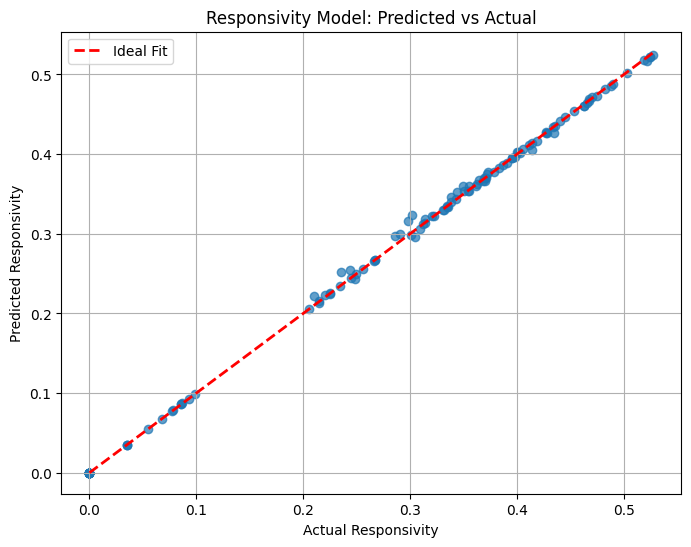

In [13]:
# =========================================================
# RESPONSIVITY MACHINE LEARNING MODEL
# =========================================================

# Features and target
X_r = r_long[['Wavelength', 'Thickness']]
y_r = r_long['Responsivity']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r,
    test_size=0.2,
    random_state=42
)

# Model
r_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
r_model.fit(X_train_r, y_train_r)

# Predict
y_pred_r = r_model.predict(X_test_r)

# Metrics
print("Responsivity Model Performance")
print("R² Score:", r2_score(y_test_r, y_pred_r))
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_r, y_pred_r, alpha=0.7)

# Ideal reference line
min_val = min(y_test_r.min(), y_pred_r.min())
max_val = max(y_test_r.max(), y_pred_r.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Responsivity")
plt.ylabel("Predicted Responsivity")
plt.title("Responsivity Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =========================================================
# PREDICT CURRENT
# =========================================================

def predict_current(voltage, thickness):

    prediction = jv_model.predict([[voltage, thickness]])[0]

    print(f"Predicted Current Density at {voltage} V and {thickness} nm PVK: {prediction}")

    return prediction

In [ ]:
# =========================================================
# PREDICT QE
# =========================================================

def predict_qe(wavelength, thickness):

    prediction = qe_model.predict([[wavelength, thickness]])[0]

    print(f"Predicted QE at {wavelength} nm and {thickness} nm PVK: {prediction}")

    return prediction

In [ ]:
# =========================================================
# PREDICT RESPONSIVITY
# =========================================================

def predict_responsivity(wavelength, thickness):

    prediction = r_model.predict([[wavelength, thickness]])[0]

    print(f"Predicted Responsivity at {wavelength} nm and {thickness} nm PVK: {prediction}")

    return prediction

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

voltage = float(input("Enter Voltage (V): "))
thickness = float(input("Enter PVK Thickness (nm): "))

predict_current(voltage, thickness)

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))
thickness = float(input("Enter PVK Thickness (nm): "))

predict_qe(wavelength, thickness)

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))
thickness = float(input("Enter PVK Thickness (nm): "))

predict_responsivity(wavelength, thickness)

In [15]:
# =========================================================
# PREDICT FULL J-V CURVE
# =========================================================

def predict_jv_curve(thickness):

    voltage_range = np.linspace(
        jv_long['Voltage'].min(),
        jv_long['Voltage'].max(),
        200
    )

    X_curve = pd.DataFrame({
        'Voltage': voltage_range,
        'Thickness': thickness
    })

    predicted_current = jv_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        voltage_range,
        predicted_current,
        label=f'Predicted PVK = {thickness} nm'
    )

    plt.title("Predicted J-V Curve")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

thickness = float(input("Enter PVK Thickness (nm): "))

predict_jv_curve(thickness)

In [16]:
# =========================================================
# PREDICT FULL QE CURVE
# =========================================================

def predict_qe_curve(thickness):

    wavelength_range = np.linspace(
        qe_long['Wavelength'].min(),
        qe_long['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Thickness': thickness
    })

    predicted_qe = qe_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_qe,
        label=f'Predicted PVK = {thickness} nm'
    )

    plt.title("Predicted QE Curve")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Quantum Efficiency")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

thickness = float(input("Enter PVK Thickness (nm): "))

predict_qe_curve(thickness)

In [ ]:
# =========================================================
# PREDICT FULL RESPONSIVITY CURVE
# =========================================================

def predict_r_curve(thickness):

    wavelength_range = np.linspace(
        r_long['Wavelength'].min(),
        r_long['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Thickness': thickness
    })

    predicted_r = r_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_r,
        label=f'Predicted PVK = {thickness} nm'
    )

    plt.title("Predicted Responsivity Curve")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Responsivity")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

thickness = float(input("Enter PVK Thickness (nm): "))

predict_r_curve(thickness)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED J-V CURVE
# =========================================================

def compare_jv_actual_vs_predicted(thickness):

    # Actual SCAPS data
    actual_data = jv_long[jv_long['Thickness'] == thickness]

    if actual_data.empty:
        print("Thickness not found in dataset.")
        return

    # Predicted curve
    voltage_range = np.linspace(
        actual_data['Voltage'].min(),
        actual_data['Voltage'].max(),
        200
    )

    X_curve = pd.DataFrame({
        'Voltage': voltage_range,
        'Thickness': thickness
    })

    predicted_current = jv_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Voltage'],
        actual_data['Current'],
        label="Actual SCAPS"
    )

    plt.plot(
        voltage_range,
        predicted_current,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted J-V Curve ({thickness} nm PVK)")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

thickness = float(input("Enter Existing PVK Thickness (nm): "))

compare_jv_actual_vs_predicted(thickness)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED QE CURVE
# =========================================================

def compare_qe_actual_vs_predicted(thickness):

    # Actual SCAPS data
    actual_data = qe_long[qe_long['Thickness'] == thickness]

    if actual_data.empty:
        print("Thickness not found in dataset.")
        return

    # Predicted curve
    wavelength_range = np.linspace(
        actual_data['Wavelength'].min(),
        actual_data['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Thickness': thickness
    })

    predicted_qe = qe_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Wavelength'],
        actual_data['QE'],
        label="Actual SCAPS"
    )

    plt.plot(
        wavelength_range,
        predicted_qe,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted QE Curve ({thickness} nm PVK)")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Quantum Efficiency")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

thickness = float(input("Enter Existing PVK Thickness (nm): "))

compare_qe_actual_vs_predicted(thickness)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED RESPONSIVITY CURVE
# =========================================================

def compare_r_actual_vs_predicted(thickness):

    # Actual SCAPS data
    actual_data = r_long[r_long['Thickness'] == thickness]

    if actual_data.empty:
        print("Thickness not found in dataset.")
        return

    # Predicted curve
    wavelength_range = np.linspace(
        actual_data['Wavelength'].min(),
        actual_data['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Thickness': thickness
    })

    predicted_r = r_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Wavelength'],
        actual_data['Responsivity'],
        label="Actual SCAPS"
    )

    plt.plot(
        wavelength_range,
        predicted_r,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted Responsivity Curve ({thickness} nm PVK)")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Responsivity")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

thickness = float(input("Enter Existing PVK Thickness (nm): "))

compare_r_actual_vs_predicted(thickness)

In [ ]:
# =========================================================
# PVK THEORY + SYSTEM WORKING
# =========================================================

print("""
============================================================
PVK (PEROVSKITE ABSORBER LAYER) THEORY
============================================================

In this project, PVK represents the perovskite absorber layer 
(CH3NH3SnBr3), which is the central photoactive layer of the 
solar cell. This layer is primarily responsible for absorbing 
incident sunlight and generating electron–hole pairs.

When sunlight falls on the PVK layer:
• Photons are absorbed
• Electrons gain energy
• Electron–hole pairs are created
• These carriers move toward transport layers
• Electrical power is produced

Thus, PVK thickness directly influences how effectively the 
device captures light and converts it into electrical response.

------------------------------------------------------------
WHY PVK THICKNESS VARIATION IS STUDIED
------------------------------------------------------------

The thickness of the absorber layer affects:

• Light absorption capability
• Carrier generation
• Recombination losses
• Electrical output
• Spectral response

If PVK thickness is too low:
• Less light is absorbed
• Lower charge generation may occur

If PVK thickness increases:
• More photons may be absorbed
• Current output may improve

However, excessive thickness can also increase recombination, 
which may influence device behavior.

Therefore, studying PVK thickness variation helps analyze how 
different absorber thicknesses affect:
• J–V Characteristics
• Quantum Efficiency
• Responsivity

------------------------------------------------------------
ROLE OF SCAPS DATASET
------------------------------------------------------------

The Excel dataset used here is generated from SCAPS simulations.

For each PVK thickness, SCAPS provides:

1. J–V Data:
Voltage vs Current Density

2. QE Data:
Wavelength vs Quantum Efficiency

3. Responsivity Data:
Wavelength vs Responsivity

Each thickness value therefore represents a complete simulated 
solar-cell behavior under specific absorber conditions.

------------------------------------------------------------
WHAT THIS ML SYSTEM DOES
------------------------------------------------------------

Instead of manually analyzing every PVK thickness separately, 
Machine Learning is used to learn patterns from SCAPS data.

Three Random Forest models are trained:

J–V Model:
(Voltage + Thickness) → Current

QE Model:
(Wavelength + Thickness) → QE

Responsivity Model:
(Wavelength + Thickness) → Responsivity

This allows prediction of:
• Current at user-defined voltage
• QE at user-defined wavelength
• Responsivity at user-defined wavelength
• Full predicted curves for selected thickness

------------------------------------------------------------
MODEL VALIDATION
------------------------------------------------------------

To ensure reliability:
• R² Score is used for prediction accuracy
• MAE is used for prediction error
• Predicted vs Actual plots compare model performance

This helps verify how effectively ML captures SCAPS trends.

------------------------------------------------------------
ACTUAL vs PREDICTED COMPARISON
------------------------------------------------------------

For existing PVK thickness values:
• Actual SCAPS curves are plotted
• Predicted ML curves are plotted

This comparison helps evaluate:
• Learning quality
• Pattern recognition
• Predictive consistency

------------------------------------------------------------
SYSTEM SIGNIFICANCE
------------------------------------------------------------

This framework combines:
SCAPS Simulation + Data Processing + Machine Learning

Therefore, it serves as:
• Simulation analysis tool
• Predictive modeling system
• Visualization framework

Rather than replacing SCAPS, it extends SCAPS by enabling 
faster prediction, easier comparison, and reusable analysis 
for PVK thickness variation.

============================================================
FINAL SUMMARY
============================================================

PVK is the active absorber layer.
Its thickness affects optical and electrical performance.
SCAPS provides simulation data.
Machine Learning learns simulation behavior.
The final system predicts and visualizes PVK trends.

In short:
This project creates a PVK-based simulation and prediction 
framework for perovskite solar-cell analysis.
============================================================
""")